## Electricity Consumption & Day-Ahead Price Forecast

**Data source:** [smard.de – Strommarktdaten](https://www.smard.de)

![dawd](resources/images.png)

<img src="resources/roadmap.png" width="800"/>

This study works with a time series. In particular energy prices for which we want to build
a forecasting model. Other types of models or studies for time series include:

Classification, Intervention Analysis, Segmentation, Descriptive Analysis

---

### 1 · Understand the Market  
- Overview on how the German electricity market works.  
- Clarify the mechanism that sets day-ahead prices.

### 2 · Exploratory Analysis  
1. **Trend & seasonality**  
2. **Autocorrelation diagnostics**  
3. **Day-of-week effects**

### 3 · Baseline Forecast  
- **Seasonal naïve** benchmark

### 4 · First Statistical Models  
1. **Auto-ARIMA**  
2. **Prophet**  
3. **MSTL decomposition + ETS**

### 5 · Add Exogenous Regressors  
- Weather variables: temperature, wind speed, sunshine hours

---






### 1. Understanding the Market

- The energy market is supply and demand based
- Unlike other markets, energy is very difficult to store, so demand should to meet supply at any given time
- This is one aspect that drives the electricity price fluctuations throughou the day
- There are different energy markets with different prices
- Energy can be traded years in advance on e.g on long-term future markets or short-term spot markets.
- Another market is the day-ahead market, which aims to trade electricity for the following day.
- Bids must be submitted on the previous day.
- All market participants are obliged to hold true to how much they supply and demand according to what was decided.
- If lets say a supplier finds out they will produce more tomorrow they need to sell that on a market before the time comes.
- If they cannot sell it until the time comes they have to pay for *Balancing Services* to fix the issue.
- These aim to keep the grid frequency stable at 50 or 60 Hz.
- Day ahead prices are usually determined in a 15 minute or 1 hour interval depending on the country
- Participants submit offers for supply and demand which determines the price
- In germany there is the so-called merit order, meaning that the energy price will be the minimum needed to supply the necessary electricity given bids at different prices. I.e if there is a cheap supply bid from a wind park and an expensive bid from a coal plant, the bid price from the coal plant will be the energy price.


#### Working Example of Price Exploration:

Simplified Order Book:

| Plant / Bid type | Bid Volume (MW) | Bid Price (€/MWh) | Cumulative Volume (MW) |
|------------------|-----------------|-------------------|------------------------|
| Wind             | 2 000           | -2                | 2 000                  |
| Solar            | 1 500           | 0                 | 3 500                  |
| Nuclear          | 1 000           | 10                | 4 500                  |
| Lignite          | 1 500           | 25                | 6 000                  |
| Coal             | 1 000           | 50                | 7 000                  |
| Gas              | 500             | 100               | 7 500                  |

Visualization of the Order Book:

<img src="resources/price_exploration_plot.png" width="600"/>

Below is a step-by-step working example that mirrors the way the German (EPEX SPOT DE-LU) Day-Ahead auction discovers its hourly price.

1. Blind Auction Closes (12:00 CET):

- Market participants submit buy & sell orders for every hour of the next day. EPEX (an European electricity exchange) aggregates them into one supply and one demand curve per hour. The process is governed by the SDAC/EUPHEMIA algorithm and the merit-order principle, where bids are sorted by marginal cost and the intersection sets the Market-Clearing Price (MCP).


2. Merit-order supply curve

- The table and plot you see come from a toy order book with six typical bid types (wind → gas).
Cumulative supply reaches demand (4 800 MW) part-way through lignite, so the MCP is 25 €/MWh and every executed trade settles at that price.
All bids cheaper than 25 € are fully dispatched; bids above it are left out (or partly filled if they straddle the intersection).


3. Of course this a very simplified example. In reality there are block or complex orders with combinatorial constraints. Then there are cross boarder flows and higher resolution submarkets which are fed into the hourly resolution:
 
| Real-world feature | How it affects price discovery |
|--------------------|--------------------------------|
| **Block & complex orders** (e.g. minimum-income, ramping constraints) | Euphemia checks combinatorial constraints, which can shift the intersection or trigger paradoxically rejected bids. |
| **Cross-border flows & ATC / flow-based capacity** | Interconnector capacity lets cheaper neighbouring supply in; congestion rents arise when extra flows would violate network limits, so the DE-LU price can diverge from FR/NL/PL etc. |
| **Price limits** (–500 €/MWh … +4 000 €/MWh since 1 Jul 2024) | Prevents runaway bids but still allows negative prices when low-cost supply exceeds demand. |
| **Co-optimised 15-minute products & quarter-hourly granularity** | Adds flexibility, especially in high-RES hours; sub-curves clear separately but feed into hourly MCP via linked block orders. |

1. Interpreting the outcome

    If RES (Renewable Energy Sources) output increases, the supply curve shifts right; the intersection moves left/down → lower MCP.

    A gas-price spike shifts the top of the curve up; when demand occasionally intersects a gas bid, the MCP jumps—this is why fuel & CO₂ prices propagate into power prices.

    Negative prices arise when low-/no-cost bids (wind/solar, must-run CHP) already exceed demand before any positive-price bids appear.


**Resources for this Study:**
1. https://www.smard.de/page/en/wiki-article/5884/5840
2. https://www.machinelearningplus.com/time-series/augmented-dickey-fuller-test/
3. https://medium.com/@data-overload/evaluating-time-series-forecasting-models-a-guide-to-measuring-accuracy-aa99114ee0b0

### 2. Exploratory Analysis

In [1]:
import pandas as pd
import numpy as np

START_DATE = "Datum von"
END_DATE = "Datum bis"
PRICE_COL = "Deutschland/Luxemburg [€/MWh]"

df_price = pd.read_excel("Day Ahead Prices 23 25.xlsx", skiprows=9)
df_price[START_DATE] = pd.to_datetime(df_price[START_DATE], format="%d.%m.%Y %H:%M", errors="raise")
df_price[END_DATE] = pd.to_datetime(df_price[END_DATE], format="%d.%m.%Y %H:%M", errors="raise")

price_columns = list(filter(lambda x: "€/MWh" in x, df_price.columns))

df_price[price_columns] = df_price[price_columns].replace("-", np.nan, regex=True)
df_price[price_columns] = df_price[price_columns].astype(float)
df_price

/home/nick/venvs/deeplib_venv/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/tmp/ipykernel_15018/979370899.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_price[price_columns] = df_price[price_columns].replace("-", np.nan, regex=True)


,Datum von,Datum bis,Deutschland/Luxemburg [€/MWh],∅ Anrainer DE/LU [€/MWh],Belgien [€/MWh],Dänemark 1 [€/MWh],Dänemark 2 [€/MWh],Frankreich [€/MWh],Niederlande [€/MWh],Norwegen 2 [€/MWh],Österreich [€/MWh],Polen [€/MWh],Schweden 4 [€/MWh],Schweiz [€/MWh],Tschechien [€/MWh],DE/AT/LU [€/MWh],Italien (Nord) [€/MWh],Slowenien [€/MWh],Ungarn [€/MWh]
0,2023-01-01 00:00:00,2023-01-01 00:15:00,-5.17,NaN,-4.39,2.01,2.01,0.00,-3.61,119.32,12.06,18.09,2.01,0.03,4.84,NaN,195.90,13.31,19.76
1,2023-01-01 00:15:00,2023-01-01 00:30:00,-5.17,NaN,-4.39,2.01,2.01,0.00,-3.61,119.32,12.06,18.09,2.01,0.03,4.84,NaN,195.90,13.31,19.76
2,2023-01-01 00:30:00,2023-01-01 00:45:00,-5.17,NaN,-4.39,2.01,2.01,0.00,-3.61,119.32,12.06,18.09,2.01,0.03,4.84,NaN,195.90,13.31,19.76
3,2023-01-01 00:45:00,2023-01-01 01:00:00,-5.17,NaN,-4.39,2.01,2.01,0.00,-3.61,119.32,12.06,18.09,2.01,0.03,4.84,NaN,195.90,13.31,19.76
4,2023-01-01 01:00:00,2023-01-01 01:15:00,-1.07,NaN,-1.75,1.38,1.38,-0.10,-1.46,108.83,-0.10,5.75,1.38,-7.25,-0.35,NaN,191.09,-0.07,0.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70267,2025-01-01 22:45:00,2025-01-01 23:00:00,10.05,43.35,32.07,10.05,9.84,34.69,46.37,26.49,101.05,9.71,9.80,103.56,93.24,NaN,150.00,124.62,86.45
70268,2025-01-01 23:00:00,2025-01-01 23:15:00,7.01,37.92,25.49,7.01,7.01,28.04,38.00,25.76,90.99,0.04,7.01,102.74,85.01,NaN,135.99,90.99,45.45
70269,2025-01-01 23:15:00,2025-01-01 23:30:00,7.01,37.92,25.49,7.01,7.01,28.04,38.00,25.76,90.99,0.04,7.01,102.74,85.01,NaN,135.99,90.99,45.45
70270,2025-01-01 23:30:00,2025-01-01 23:45:00,7.01,37.92,25.49,7.01,7.01,28.04,38.00,25.76,90.99,0.04,7.01,102.74,85.01,NaN,135.99,90.99,45.45


##### Fixing Summer and Wintertime change

The data contains the day ahead prices at a 15 minute resolution in German local time. This means, that during winter- or summertime change
there is either a duplicate or a gap i.e

...
1:30
1:45
1:00
1:15
1:30
...

...
1:30
1:45
2:00
2:15
2:30
...

In [2]:
fixed_differences = df_price[START_DATE].diff().fillna(df_price[START_DATE].diff().median())
df_price[START_DATE + "_cont"] = df_price[START_DATE] - (fixed_differences - df_price[START_DATE].diff().median()).cumsum()

The following provides a visual overview of the price data

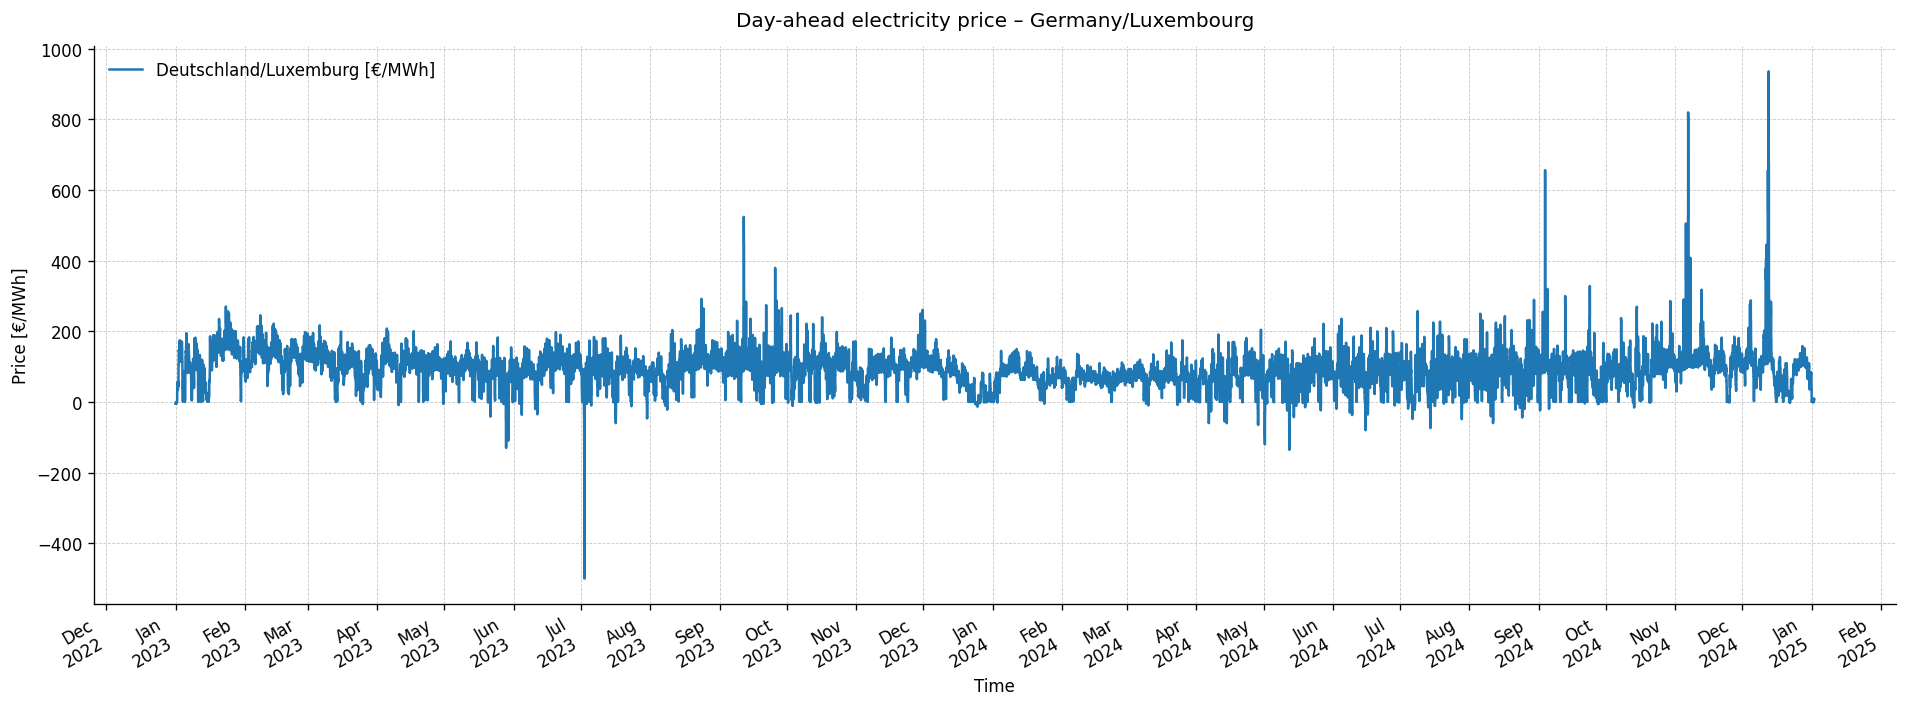

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- BASIC FIGURE SETUP ------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 6), dpi=120)      # one clear axes object

# --- THE ACTUAL STEP PLOT ----------------------------------------------------
ax.step(
    df_price[START_DATE],                            # ensure dtype is datetime
    df_price[PRICE_COL],
    where="post",
    linewidth=1.5,
    label=PRICE_COL,
)

# --- AXIS & GRID POLISH ------------------------------------------------------
ax.set_title("Day-ahead electricity price – Germany/Luxembourg", pad=12)
ax.set_xlabel("Time")
ax.set_ylabel("Price [€/MWh]")

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)  # light dashed grid
ax.spines["top"].set_visible(False)                      # unclutter frame
ax.spines["right"].set_visible(False)

# --- DATE TICK FORMATTING ----------------------------------------------------
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.autofmt_xdate()                                      # smart label angle

# --- LEGEND & LAYOUT ---------------------------------------------------------
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

### Seasonal Decomposition

A seasonal decompositon is usually the following

$Y[t] = T[t] + S[t] + r[t]$

where T represents an overall trend, S a seasonality and r the residue.

Explicitly the trend $T$ would be determined as follows:
```
trend = df_price["Germany/Luxembourg [€/MWh]"].rolling(24*4).mean()
fig = plt.figure(figsize=(10, 2))
plt.plot(df_price["Start date"].tolist(), trend, label="Germany/Luxembourg [€/MWh]")
plt.show()
```

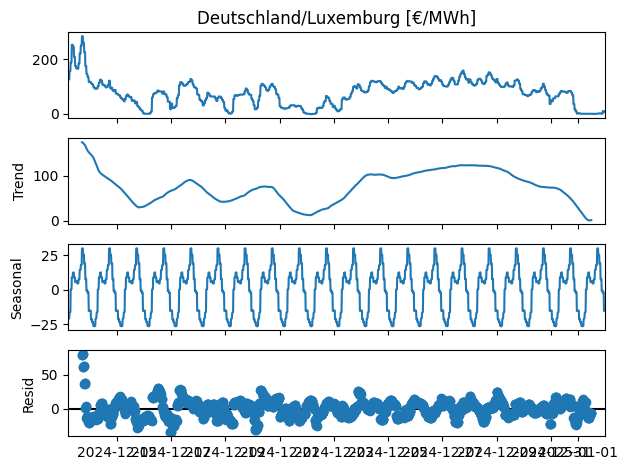

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_price.set_index(START_DATE).iloc[-1900:][PRICE_COL], model='additive', period=24 * 4)
result.plot()
plt.show()

result_trend = result.trend.dropna()
result_seasonal = result.seasonal.dropna()
result_residual = result.resid.dropna()

### Dickey-Fuller Test

**Why do we need this test?**

In ARIMA time series forecasting, the first step is to determine the number of differencing required to make the series stationary (explained below).
Since testing the stationarity of a time series is a frequently performed activity in autoregressive models, 
the ADF (Augmented Dickey Fuller) test along with KPSS test is something required to perform time series analysis.

![](resources/stationary_example.jpg)


**How does it work?**

- Given a time series $y_t = \alpha + \epsilon_t +  \sum a_j y_{t-j}$ we want to find out if its statistical properties remain the same when shifted in time.
- A time series where these properties remain the same is called a stationary process.
- A certain type of time series that depends linearly on its previous values and on a stochastic term is called an autoregressive model.
- Lets regard a simple autoregressive model $y_t = \alpha + \rho y_{t-1} + \epsilon_t$
- In statistics a stochastic process $(y_t)$ is called (weakly) stationary, if $E[y_t] \equiv const.$, $Var(y_t) = \gamma_0 < \infty$ and $y_k = Cov(y_t, y_{t-k})$ is a function of $k$ and not $t$.
- For the simple model above, this means: If $\rho < 1$ one can show that stationarity holds, while this is not true for $\rho = 1$  (random walk) and $\rho > 1$ (exploding sequence).
- Now the Dickey Fuller Test is a hypothesis test that tests $H_0: \rho = 1$ versus $H_1: \rho < 1 $.
- In order to perform the test we regard $\Delta y_t = \alpha + (\rho - 1) y_{t-1} + \epsilon_t \eqqcolon \alpha + \delta y_{t-1} + \epsilon_t$. and test for $H_0: \delta = 0$ against $H_1: \delta < 0$. 
- If we assume the $\epsilon_t$ are iid normally distributed, then it turns out that $\hat{\delta} = argmin_{\delta} \lVert \Delta y_{t} - \delta y_{t-1} - \alpha \rVert^2$ is a maximum likelihood estimator.
- Now this is an ordinary least squares problem one can solve using e.g. the Gaussian formula, i.e if $X = [1 | y_t] \in \R^{n \times 2}$ we have $\hat{\delta} = argmin_{\delta} \lVert \Delta y_{t} - X[\alpha, \delta]^\top \rVert^2$ and hence $X^\top X  [\hat{\alpha}, \hat{\delta}]^\top = X^\top \Delta y_{t}$.
- And we arrive at estimators $\hat{\delta}$ and $\hat{\alpha}$.
- Now we regard the statistic $\tau_{DF} = \hat{\delta} / \sqrt{Var(\hat{\delta})}$. One would naively assume that this is $t$-Student distributed but because we dont apriori know if the $y_t$ are iid, this is not the case. Instead it follows a Dickey-Fuller distribution. A table can be used to determine a $p$-value.
- There are different formulations of this simple autoregressive model:


| Model Type         | Formula                                         | statsmodels.tsa stattools.adfuller arguments
|--------------------|---------------------------------------------|----|
| AR(1) = ADF(0), no constant no trend              | $y_t = \rho y_{t-1} + \epsilon_t$      | regression="n"
| AR(1) = ADF(0), constant only              | $y_t = \alpha + \rho y_{t-1} + \epsilon_t$      | regression = "c"
| AR(p), constant only              | $y_t = \alpha + \sum_{j=1}^p a_j y_{t-j} + \epsilon_t$ |
| AR(1) = ADF(0), constant linear              | $y_t = \alpha + \beta t + \rho y_{t-1} + \epsilon_t$      | regression = "ct"
| AR(1) = ADF(0), constant linear quadratic              | $y_t = \alpha + \beta t + \gamma t^2 + \rho y_{t-1} + \epsilon_t$      | regression = "ctt"
| ADF(p), constant linear              | $y_t = \alpha + \beta t + \rho y_{t-1} + \delta_1 \Delta y_{t-1} + \ldots + \delta_{p} \Delta y_{t-p} + \epsilon_t$      | regression = "ct", maxlag = p

In practice the more versatile augmented Dickey Fuller test is used where the stochastic process is assumed to have the above representation.

Let's apply this to our price data:

In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, **kwargs):
    result = adfuller(series, autolag="AIC", **kwargs)
    print('Augmented Dickey-Fuller Test:')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    print("------------------------------")
    print()

# here we expect no unit root, so the p-value should be low. While we do have a trend, we can use the regression='ct' option to account for it.
adf_test(df_price[PRICE_COL] + np.array([10 * i for i in range(len(df_price))]), regression='ct')

# on the other hand, if we remove the trend, we expect a unit root in the residuals
adf_test(df_price[PRICE_COL] + np.array([100 * i for i in range(len(df_price))]), regression='c')

# and now we can also test the original series, which should not have a unit root
adf_test(df_price[PRICE_COL], regression='c')


Augmented Dickey-Fuller Test:
ADF Statistic: -19.154208328909657
p-value: 0.0
Critical Values:
   1%: -3.958898947101181
   5%: -3.4105525333453017
   10%: -3.127086826934632
------------------------------

Augmented Dickey-Fuller Test:
ADF Statistic: -0.19089535089646387
p-value: 0.9395982015272037
Critical Values:
   1%: -3.4304431412327903
   5%: -2.8615811667731847
   10%: -2.566791911666377
------------------------------

Augmented Dickey-Fuller Test:
ADF Statistic: -18.792163780270712
p-value: 2.0233876605929754e-30
Critical Values:
   1%: -3.4304431412327903
   5%: -2.8615811667731847
   10%: -2.566791911666377
------------------------------



### Weekday Effects:

/tmp/ipykernel_15018/2745937808.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_price.groupby("Weekday")[PRICE_COL]
/tmp/ipykernel_15018/2745937808.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


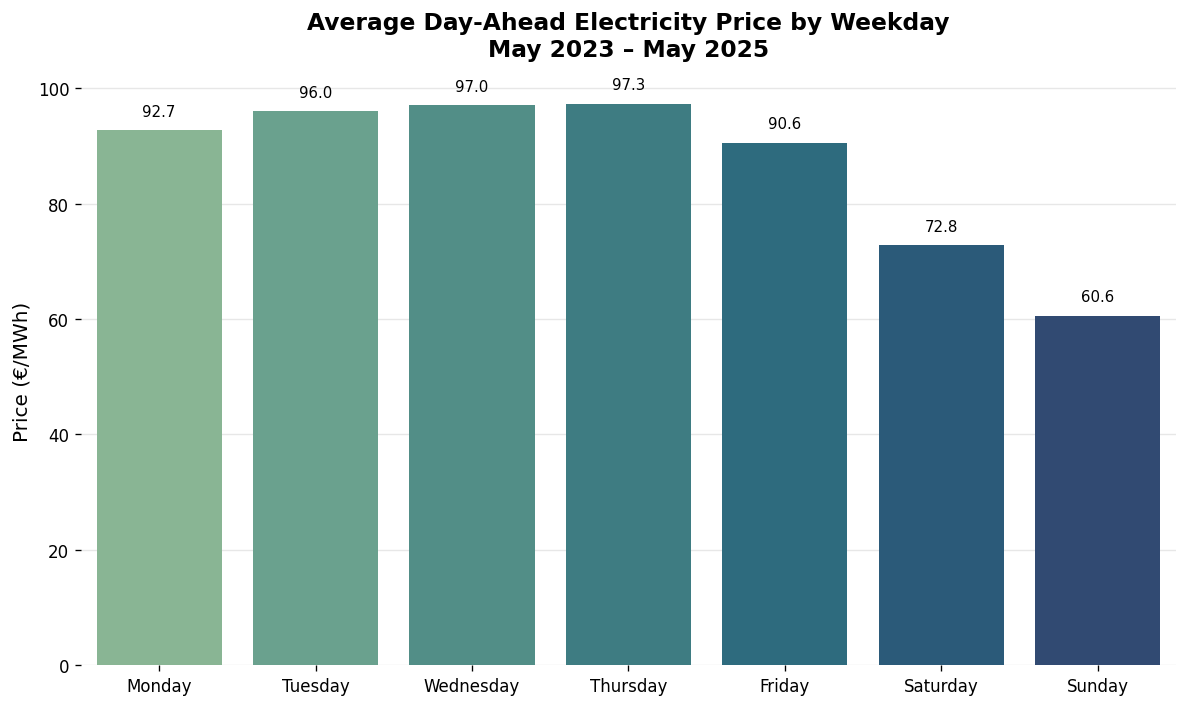

In [6]:
import seaborn as sns  # for the nicer colour palette

# -------------------------------------------------------------
# 1.  Prepare an ordered weekday factor so the bars read Mon→Sun
# -------------------------------------------------------------
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df_price["Weekday"] = pd.Categorical(
    df_price[START_DATE].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

avg_price = (
    df_price.groupby("Weekday")[PRICE_COL]
            .mean()
            .reindex(weekday_order)        # guarantees bar order
)

plt.figure(figsize=(10, 6), dpi=120)
sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette="crest"            # gentle gradient, colour-blind-safe
)

plt.title(
    "Average Day-Ahead Electricity Price by Weekday\nMay 2023 – May 2025",
    fontsize=14, weight="bold", pad=12
)
plt.ylabel("Price (€/MWh)", fontsize=12)
plt.xlabel("")                        # y-axis label only
plt.xticks(rotation=0, fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.gca().set_axisbelow(True)         # grid behind bars
sns.despine(left=True, bottom=True)

for i, v in enumerate(avg_price.values):
    plt.text(i, v + 2, f"{v:,.1f}",    # +2 so labels sit just above
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


### Autocorrelation

### Baseline Forecast

 The baseline forecast is just a dummy forecast that justs claculates the flat mean as the constant forcast. Of course this
 is useless in the sense of actually predicting a future price, but its enough to showcase the tools and the evalutation
 techniques later used for more sophisicated models.

In [7]:
y = df_price.set_index(df_price[START_DATE + "_cont"])[PRICE_COL]


def flat_mean_forecast(series, horizon=1, k_days=15, concat_with_series=True):
    """
    Forecast `horizon` steps ahead using the flat mean
    of the last `k_days` worth of data.
    """
    # 1. Define the forecast index
    freq   = series.index.freq or pd.infer_freq(series.index)
    offset = pd.tseries.frequencies.to_offset(freq)
    last_date = series.index[-1]

    forecast_index = pd.date_range(start=last_date + offset,
                                   periods=horizon,
                                   freq=freq)

    # 2. Calculate the mean of the last `k_days`
    k_days = min(k_days, len(series))  # ensure k_days does not exceed series length
    mean_value = series[-(k_days * 96):].mean()  # 96 quarter-hours in a day
    # 3. Create the forecast series
    forecast_series = pd.Series(mean_value, index=forecast_index)
    if concat_with_series:
        # 4. Concatenate with the original series
        forecast_series = pd.concat([series, forecast_series])
    return forecast_series


#### Obtaining a Train and Test Dataset from the Data:

Since we have  a time series, all of the data points are connected to their neighbors. To obtain a train test split we simply choose a cutoff point
and divide the data according to that cutoff point i.e everything before the cutoff point is the training data and everything after it is test data. 
The training set should be roughly 70-80% of the full dataset. Optionally we may also use a validation set which would chronologically appear between 
the training and test dataset.

In [8]:
import sklearn as sk

def plot_forecast_and_metrics(model_name: str, t_cutoff: int, y_train: pd.Series, y_test: pd.Series, y_forecast: pd.Series):

    # --- PLOT THE FORECAST --------------------------------------------------------
    plt.figure(figsize=(16, 6), dpi=120)
    plt.plot(y_train.index, y_train, label="Train", color="blue", linewidth=1.5)
    plt.plot(y_test.index, y_test, label="Test", color="orange", linewidth=1.5)
    plt.plot(y_forecast.index, y_forecast, label=f"{model_name} Forecast", color="green", linewidth=1.5)
    plt.axvline(t_cutoff, color="red", linestyle="--", label="Cutoff Date")
    plt.title(f"{model_name} Forecast of Day-Ahead Electricity Prices")
    plt.xlabel("Time")
    plt.ylabel("Price [€/MWh]")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    metrics = pd.Series(
        [
            sk.metrics.mean_absolute_error(y_test, y_forecast[t_cutoff:]),
            sk.metrics.mean_squared_error(y_test, y_forecast[t_cutoff:]),
            sk.metrics.mean_absolute_percentage_error(y_test, y_forecast[t_cutoff:]),
            sk.metrics.root_mean_squared_error(y_test, y_forecast[t_cutoff:]),
        ],
        index=["MAE", "MSE", "MAPE", "RMSE"],
        name="Flat Mean Forecast Errors"
    )

    return metrics

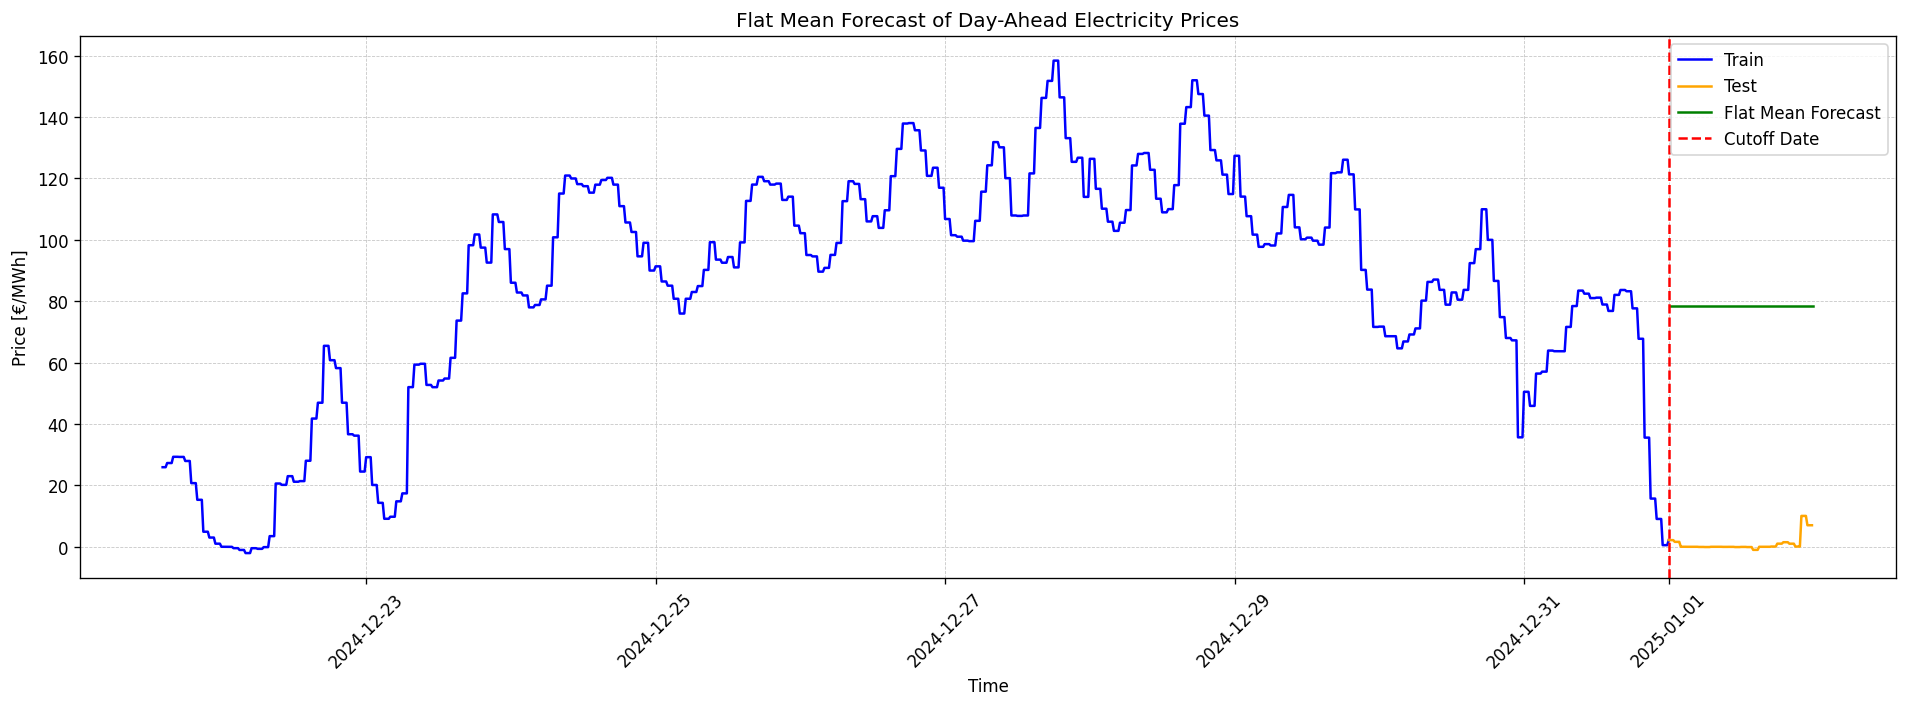

MAE     7.753652e+01
MSE     6.017778e+03
MAPE    1.472885e+16
RMSE    7.757434e+01
Name: Flat Mean Forecast Errors, dtype: float64

: 

In [ ]:
t_cutoff = y.index[-24 * 4]

y_train = y[:t_cutoff]
y_test = y[t_cutoff:]

y_forecast = flat_mean_forecast(y_train, horizon=len(y_test), k_days=15, concat_with_series=False)
plot_forecast_and_metrics("Flat Mean", t_cutoff=t_cutoff, y_train=y_train[-1000:], y_test=y_test, y_forecast=y_forecast)

### ARMA(p, q) Model

Next we want to use an ARMA(p,q) Model that I have implemented. It is very slow compared to the library we will use as it is not optimized and the gradients are not computed analytically. The sole purpose is to demonstate how an ARMA model works on a smaller datset:

#### What is an ARMA Time Series Model?

An ARMA (Auto Regressive, Moving Average) is a time series prediction Model for stationary time series. Above we have seen what a stationary time series and how we can test for stationarity in the case where it is not clear. The ARMA model cobines the auto regressive model and the moving average model. The first one predicts a future value by a weighted sum of its previous values, while the moving average model predicts a future value by its mean plus a weighted sum of the errors made for the past predicted values. Together we have the following equation:

$$X_t = \mu + \sum_{i=1}^p \phi_i X_{t-i} + \sum_{j=1}^q \theta_i \varepsilon_{t-j} + \varepsilon_{t}$$

Evalutation is done recursively.

We will train the ARMA model with p = 96 (the next prediction has access to the last 24 hours of data) as well as a smaller q = 3 to incorperate more shortterm errors.

In [ ]:
# from statsmodels.tsa.arima.model import ARIMA
# import pickle as pk

# model = ARIMA(y_train, order=(96, 0, 3))
# model_fit = model.fit()


# with open("arimafit.pickle", "wb") as handle:
#     pk.dump(model_fit, handle)


import pmdarima as pm

model = pm.auto_arima(y_train, seasonal=True, m=96, trace=True)
y_forecast = model.predict(n_periods=len(y_test))


/home/nick/venvs/deeplib_venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/nick/venvs/deeplib_venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/nick/venvs/deeplib_venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/nick/venvs/deeplib_venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/nick/venvs/deeplib_venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'e

Performing stepwise search to minimize aic


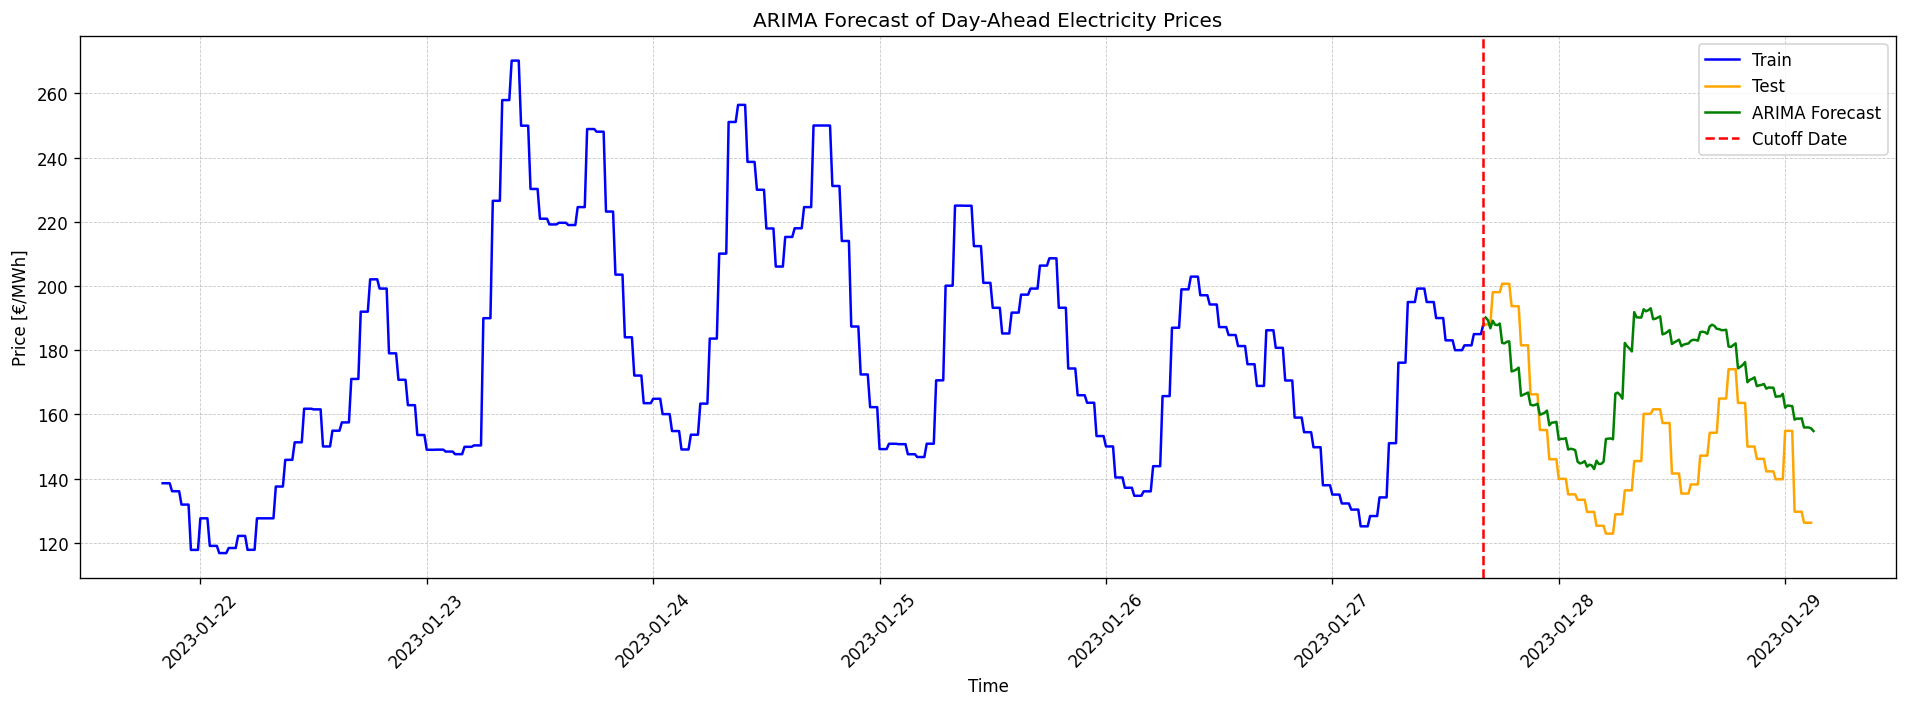

MAE      23.268645
MSE     723.104853
MAPE      0.160914
RMSE     26.890609
Name: Flat Mean Forecast Errors, dtype: float64

In [ ]:
forecast = model_fit.forecast(steps=y_test.shape[0])


plot_forecast_and_metrics(model_name = "ARIMA", t_cutoff = y_train.index[-1],
                          y_train = y_train, y_test = y_test,
                          y_forecast = forecast)